LinearRegression()


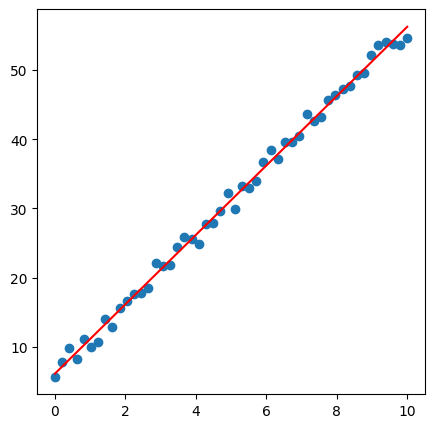

[[5.01696255]]
[6.10836331]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 线性回顾 Linear Regression

#模拟数据
x = np.linspace(0, 10, 50)
noise = np.random.uniform(-2,2,size=50)
y = 5 * x + 6 + noise
#创建模型
liner = LinearRegression()
#拟合模型
liner.fit(np.reshape(x,(-1,1)),np.reshape(y,(-1,1)))
print(liner)
#预测
y_pred = liner.predict(np.reshape(x,(-1,1)))
plt.figure(figsize=(5,5))
plt.scatter(x,y)
plt.plot(x,y_pred, color="r")
plt.show()
print(liner.coef_)
print(liner.intercept_)

In [2]:
#线性回归算法一般用于解决”使用已知样本对未知公式参数的估计“类问题
#获取数据
    # 股票数据特征:开盘价(Open)、最高价(High)、最低价(Low)、收盘价(Close)、交易额(Volume)
    # 及调整后的开盘价(Adj. Open)、最高价(Adj. High)、最低价(Adj. Low)、收盘价(Adj. Close)、交易额(Adj. Volume)
#数据预处理
    #除权后的数据更能反映数据特征，选择调整后的数据为主要使用的数据特征
    #两个数据特征：HL_PCT(股票最高价与最低价变化百分比)、PCT_change(股票收盘价与最低价的变化百分比)
    #自变量为：Adj.Close、HL_PCT、PCT_change、Adj.Volume
    #因变量为：Adj.Close

import quandl
from sklearn import preprocessing
df = quandl.get('WIKI/GOOGL')
# df = quandl.get('WIKI/AAPL')
# print(df)

import math
import numpy as np
#定义预测列变量，存放研究对象的标签名
forecast_col = 'Adj. Close'
#定义预测天数，这里设置为所有数据量长度的1%
forecast_out = int(math.ceil(0.01*len(df)))
#只用到df中的下面几个字段
df = df[['Adj. Open','Adj. High','Adj. Low','Adj. Close','Adj. Volume']]
#构造两个新列
df['HL_PCT'] = (df['Adj. High']-df['Adj. Close'])/df['Adj. Close']*100.0
df['PCT_change'] = (df['Adj. Close']-df['Adj. Open'])/df['Adj. Open']*100.0
#真正用到的特征
df = df[['Adj. Close','HL_PCT','PCT_change','Adj. Volume']]
#处理空值，这里设置为-99999
df.fillna(-99999, inplace=True)
#label代表预测结果，通过让Adj. Close列的数据往前移动1%行来表示
df['label'] = df[forecast_col].shift(-forecast_out)
#生成在模型中使用的数据X,y,以及预测时用到的数据X_lately
X = np.array(df.drop(['label'],1))
X = preprocessing.scale(X)
#上面生成的label列时留下的最后1%行的数据，这些行并没有label 数据，用作预测时用到的输入数据
X_lately = X[-forecast_out:]
X = X[:-forecast_out]
#抛弃label列中为空的那些行
df.dropna(inplace=True)
y = np.array(df['label'])

from sklearn import model_selection,svm
from sklearn.linear_model import LinearRegression
#先把X，y数据分成两部份，训练和测试
X_train,X_test,y_train,y_test = model_selection.train_test_split(X,y,test_size=0.2)
#生成线性回归对象
clf = LinearRegression(n_jobs=-1)
#开始训练
clf.fit(X_train,y_train)
#用测试数据评估准确性
accuracy = clf.score(X_test,y_test)
#进行预测
foreca_set = clf.predict(X_lately)
print(foreca_set,accuracy)

import matplotlib.pyplot as plt
from matplotlib import style
import datetime
#修改matplotlib样式
style.use('ggplot')
one_day = 86400
#在df中新建Forecast列，用于存放预测结果的数据
df['Forecast'] = np.nan
#取df最后一行的时间索引
last_date = df.iloc[-1].name
last_unix = last_date.timestamp()
next_unix = last_unix+one_day
#遍历预测结果，用它向df中追加行
for i in foreca_set:
    next_date = datetime.datetime.fromtimestamp(next_unix)
    next_unix+=one_day
    # [np.nan  for _ in range(len(df.columns)-1)]生成不包含Forecast字段的列表
    #而[i]是只包含Forecast字段的列表
    #拼在一起组成新行，按日期追加到df下面
    df.loc[next_date] = [np.nan  for _ in range(len(df.columns)-1)]+[i]
#绘图
df['Adj. Close'].plot()
df['Forecast'].plot()
plt.legend(loc=4)
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()



ModuleNotFoundError: No module named 'quandl'

In [ ]:
import pandas
#线性回归算法一般用于解决”使用已知样本对未知公式参数的估计“类问题
#获取数据
    # 股票数据特征:开盘价(Open)、最高价(High)、最低价(Low)、收盘价(Close)、交易额(Volume)
    # 及调整后的开盘价(Adj. Open)、最高价(Adj. High)、最低价(Adj. Low)、收盘价(Adj. Close)、交易额(Adj. Volume)
#数据预处理
    #除权后的数据更能反映数据特征，选择调整后的数据为主要使用的数据特征
    #两个数据特征：HL_PCT(股票最高价与最低价变化百分比)、PCT_change(股票收盘价与最低价的变化百分比)
    #自变量为：Adj.Close、HL_PCT、PCT_change、Adj.Volume
    #因变量为：Adj.Close

import akshare as ak
from sklearn import preprocessing
df = ak.stock_zh_a_hist(symbol="002279", period="daily", adjust="qfq")
# 选择列, 是为了改变表头
df = df[["日期","开盘","收盘","最高","最低","成交量","成交额"]]
# 变更表头
df.columns=['date', 'open', 'close', 'high', 'low', 'volume', 'amount']
# 更正排序
df['date'] = pandas.to_datetime(df['date'])
df.set_index('date', inplace=True)

import math
import numpy as np
#定义预测列变量，存放研究对象的标签名
forecast_col = 'close'
#定义预测天数，这里设置为所有数据量长度的1%
forecast_out = int(math.ceil(0.01*len(df)))
#forecast_out = 1
#只用到df中的下面几个字段
df = df[['open','high','low','close','volume']]
#构造两个新列
df['HL_PCT'] = (df['high']-df['close'])/df['close']*100.0
df['PCT_change'] = (df['close']-df['open'])/df['open']*100.0
#真正用到的特征
df = df[['close','HL_PCT','PCT_change','volume']]
#处理空值，这里设置为-99999
df.fillna(-99999, inplace=True)
#label代表预测结果，通过让Adj. Close列的数据往前移动1%行来表示
df['label'] = df[forecast_col].shift(-forecast_out)
#生成在模型中使用的数据X,y,以及预测时用到的数据X_lately
X = np.array(df.drop(['label'],1))
X = preprocessing.scale(X)
#上面生成的label列时留下的最后1%行的数据，这些行并没有label 数据，用作预测时用到的输入数据
X_lately = X[-forecast_out:]
X = X[:-forecast_out]
#抛弃label列中为空的那些行
df.dropna(inplace=True)
y = np.array(df['label'])

from sklearn import model_selection,svm
from sklearn.linear_model import LinearRegression
#先把X，y数据分成两部份，训练和测试
X_train,X_test,y_train,y_test = model_selection.train_test_split(X,y,test_size=0.2)
#生成线性回归对象
clf = LinearRegression(n_jobs=-1)
#开始训练
clf.fit(X_train,y_train)
#用测试数据评估准确性
accuracy = clf.score(X_test,y_test)
#进行预测
foreca_set = clf.predict(X_lately)
print(foreca_set,accuracy)

import matplotlib.pyplot as plt
from matplotlib import style
import datetime
#修改matplotlib样式
style.use('ggplot')
one_day = 86400
#在df中新建Forecast列，用于存放预测结果的数据
df['Forecast'] = np.nan
#取df最后一行的时间索引
last_date = df.iloc[-1].name
last_unix = last_date.timestamp()
next_unix = last_unix+one_day
#遍历预测结果，用它向df中追加行
for i in foreca_set:
    next_date = datetime.datetime.fromtimestamp(next_unix)
    next_unix+=one_day
    # [np.nan  for _ in range(len(df.columns)-1)]生成不包含Forecast字段的列表
    #而[i]是只包含Forecast字段的列表
    #拼在一起组成新行，按日期追加到df下面
    df.loc[next_date] = [np.nan  for _ in range(len(df.columns)-1)]+[i]
#绘图
df['close'].plot()
df['Forecast'].plot()
#plt.title(label='英飞拓')
plt.legend(loc=4)
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()



In [ ]:
# 曲线拟合——最小二乘法(Ordinary Least Square，OLS)
# https://blog.csdn.net/llittleSun/article/details/115045660
import numpy as np
import matplotlib.pyplot as plt
import numpy.linalg as lg

t=np.arange(1,17,1)
y=np.array([4,6.4,8,8.8,9.22,9.5,9.7,9.86,10,10.20,10.32,10.42,10.5,10.55,10.58,10.6
])
plt.figure()
plt.plot(t,y,'k*')
# y=at^2+bt+c

A=np.c_[t**2,t,np.ones(t.shape)]

w=lg.inv(A.T.dot(A)).dot(A.T).dot(y)

plt.plot(t,w[0]*t**2+w[1]*t+w[2])
plt.show()


[-0.04446604  1.06596674  4.38748214]
[ 5.40898284  6.34155147  7.18518803  7.93989251  8.60566492  9.18250525
  9.67041352 10.06938971 10.37943382 10.60054587 10.73272584 10.77597374
 10.73028957 10.59567332 10.372125   10.05964461]


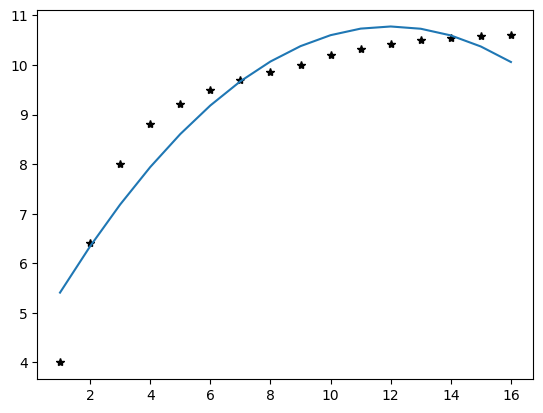

In [1]:
# 曲线拟合——最小二乘法(Ordinary Least Square，OLS)
# https://blog.csdn.net/llittleSun/article/details/115045660
import numpy as np
import matplotlib.pyplot as plt
import numpy.linalg as lg

t=np.arange(1,17,1)
y=np.array([4,6.4,8,8.8,9.22,9.5,9.7,9.86,10,10.20,10.32,10.42,10.5,10.55,10.58,10.6
])
plt.figure()
plt.plot(t,y,'k*')
# y=at^2+bt+c

A=np.c_[t**2,t,np.ones(t.shape)]
w1=lg.inv(A.T.dot(A))
w2=w1.dot(A.T)
w3=w2.dot(y)
w=lg.inv(A.T.dot(A)).dot(A.T).dot(y)
print(w)
wx=w[0]*t**2+w[1]*t+w[2]
print(wx)
plt.plot(t,wx)
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures


def uniform(size):
    x = np.linspace(0,1,size)
    return x.reshape(size,1)

def create_data(size):
    x = uniform(size)
    np.random.seed(42)
    y = sin_fun(x)+np.random.normal(scale=0.15, size=x.shape)
    return x,y

def sin_fun(x):
    return np.sin(2*np.pi*x)

X_train,y_train = create_data(10)
X_test = uniform(100)
y_test = sin_fun(X_test)

plt.scatter(X_train,y_train,facecolor="none", edgecolor="b", s=50, label="training data")
plt.plot(X_test,y_test,c="g",label="$\sin(2\pi x)$")
plt.ylabel("y",size=20)
plt.xlabel("x",size=20)
plt.legend()
plt.show()
fig = plt.figure(figsize=(12,8))
for i,order in enumerate([0,1,3,9]):
    plt.subplot(2,2,i+1)

    poly = PolynomialFeatures(order)
    X_train_ploy = poly.fit_transform(X_train)
    X_test_ploy = poly.fit_transform(X_test)

    lr = LinearRegression()
    lr.fit(X_train_ploy,y_train)
    y_pred = lr.predict(X_test_ploy)

    plt.scatter(X_train,y_train,facecolor="none", edgecolor="b", s=50, label="training data")
    plt.plot(X_test,y_pred,c="r",label="fitting")
    plt.plot(X_test,y_test,c="g",label="$\sin(2\pi x)$")
    plt.title("M={}".format(order))
    plt.legend()
plt.show()

In [5]:
A = [0.49999999999999833,-3.2999999999999905,4.599999999999989]
B = [4,2,1]
B = [1,1,1]
print(np.shape(A))
C = np.dot(A,B)
print('C =', C)

(3,)
C = 1.7999999999999967
